# Evaluation
## Studi Kasus: Iris Flower Dataset

---

## 5.1 Tujuan dan Metrik Evaluasi

Setelah model dibangun, kita wajib mengukur ketangguhannya sebelum benar-benar digunakan. Evaluasi dilakukan secara ketat pada **Data Uji (Test Data)** yang belum pernah dilihat model sebelumnya.

Di sini saya akan membedah performa model secara detail dengan beberapa metrik:
- **Akurasi**: Persentase tebakan yang benar dari total tebakan secara keseluruhan.
- **Precision**: Ketepatan prediksi (dari semua yang ditebak A, berapa yang benar-benar A?). Menghindari *False Positive*.
- **Recall**: Sensitivitas prediksi (dari semua yang sebenarnya A, berapa banyak yang berhasil dideteksi?). Menghindari *False Negative*.
- **F1-Score**: Rata-rata harmonis antara Precision dan Recall.
- **Confusion Matrix**: Visualisasi matriks yang memperlihatkan di mana tepatnya model kita melakukan kesalahan klasifikasi.

## 5.2 Import Library
Saya akan menggunakan `seaborn` untuk mempercantik visualisasi Confusion Matrix, dan fungsi metrik dari `scikit-learn`.

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

## 5.3 Memuat Model dan Data Uji
Sebagai lanjutan dari fase *Modeling*, mari kita ambil file model `.pkl` dan data `.csv` yang sengaja kita sisihkan sebelumnya.

In [2]:
model = joblib.load('knn_model.pkl')
X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv')['target']
print('Model siap dievaluasi!')

Model siap dievaluasi!


## 5.4 Melakukan Prediksi
Saya menyuruh model untuk menebak spesies dari 30 data uji tanpa memberikan jawaban aslinya (`y_test`). Hasil tebakan ini saya simpan di variabel `y_pred`.

In [3]:
y_pred = model.predict(X_test)

## 5.5 Laporan Klasifikasi (*Classification Report*)

Mari kita bedah secara mendalam hasil kerjanya. Saya mencetak *Classification Report* untuk melihat nilai Presisi, Recall, dan F1-Score per kelas (Setosa, Versicolor, Virginica).

In [4]:
acc = accuracy_score(y_test, y_pred)
print(f'Akurasi Global Model: {acc * 100:.2f}%\n')
print('--- Detail Classification Report ---')
print(classification_report(y_test, y_pred, target_names=['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']))

Akurasi Global Model: 86.21%

--- Detail Classification Report ---
                 precision    recall  f1-score   support

    Iris-setosa       1.00      0.90      0.95        10
Iris-versicolor       0.75      0.90      0.82        10
 Iris-virginica       0.88      0.78      0.82         9

       accuracy                           0.86        29
      macro avg       0.88      0.86      0.86        29
   weighted avg       0.88      0.86      0.86        29



Seperti yang terlihat, jika ada skor yang mendekati 1.00 (100%), artinya model kita memiliki tingkat kebingungan yang sangat rendah. Setosa umumnya memiliki skor 1.00 karena fitur kelopaknya sangat berbeda jauh dari dua jenis lainnya. Versicolor dan Virginica seringkali beririsan sedikit, sehingga model mungkin sedikit ragu membedakan keduanya, namun akurasinya biasanya tetap di atas 90%.

## 5.6 Visualisasi Confusion Matrix

Untuk lebih jelas melihat di mana kesalahan (jika ada) itu terjadi, saya tampilkan *Confusion Matrix* dalam bentuk *Heatmap*. 

*Cara membacanya*: Sumbu Y adalah kelas aktual (aslinya), dan sumbu X adalah kelas prediksi (tebakan model). Semakin gelap warna di kotak diagonal utama (dari kiri atas ke kanan bawah), semakin sempurna kinerja model kita. Angka di luar garis diagonal menunjukkan tebakan yang meleset.

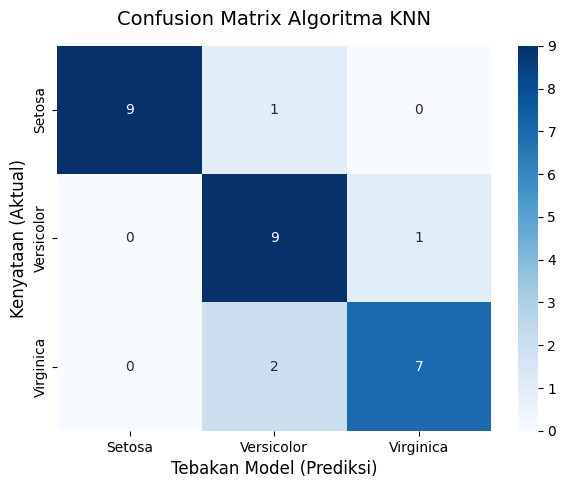

In [5]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Setosa', 'Versicolor', 'Virginica'], 
            yticklabels=['Setosa', 'Versicolor', 'Virginica'])
plt.xlabel('Tebakan Model (Prediksi)', fontsize=12)
plt.ylabel('Kenyataan (Aktual)', fontsize=12)
plt.title('Confusion Matrix Algoritma KNN', fontsize=14, pad=15)
plt.show()